In [1]:
# Phase 16 – Sensitivity Analysis | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase16"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P4  = PROJECT / "outputs" / "phase4" / "data"
P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"

print("=" * 60)
print("Phase 16 – Sensitivity Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")
print("Params: LR | Gamma | Tau | Entropy | Shock Intensity | Network Density")

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

with open(P4 / "temporal_trade_networks.pkl", "rb") as f:
    networks_by_year = pickle.load(f)
years = sorted([int(y) for y in networks_by_year.keys()])
G0 = networks_by_year[years[-1]]

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

print(f"Graph year={years[-1]} | nodes={G0.number_of_nodes()} edges={G0.number_of_edges()}")
print(f"Features {base_features.shape} | emb {emb.shape}")
print("Cell 1 completed successfully.")

Phase 16 – Sensitivity Analysis | Cell 1
Timestamp : 2026-10-05 10:37:02
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase16
Params: LR | Gamma | Tau | Entropy | Shock Intensity | Network Density
Graph year=2020 | nodes=18 edges=306
Features (378, 16) | emb (378, 32)
Cell 1 completed successfully.


Phase 16 – Cell 2: Shock intensity & density sensitivity
--- Shock intensity ---
          param         mode  value  retained_weight  weight_drop
shock_intensity strength_hub   0.10         0.935755     0.064245
shock_intensity      uniform   0.10         0.950000     0.050000
shock_intensity strength_hub   0.25         0.839388     0.160612
shock_intensity      uniform   0.25         0.875000     0.125000
shock_intensity strength_hub   0.50         0.678775     0.321225
shock_intensity      uniform   0.50         0.750000     0.250000
shock_intensity strength_hub   0.75         0.518163     0.481837
shock_intensity      uniform   0.75         0.625000     0.375000
shock_intensity strength_hub   1.00         0.357551     0.642449
shock_intensity      uniform   1.00         0.500000     0.500000

--- Network density ---
          param  target_density  actual_density  n_edges  total_weight  retained_after_hub_attack
network_density            0.30        0.300654       46  3.417609e+09

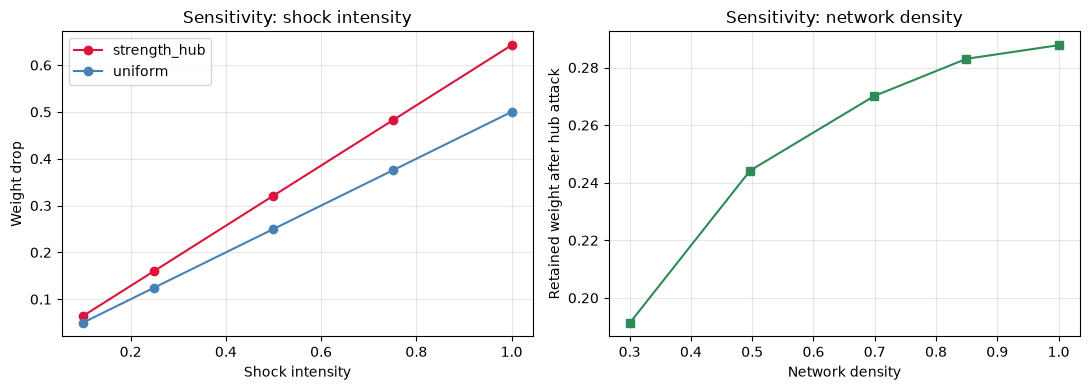

Cell 2 completed successfully.


In [3]:
# Phase 16 – Cell 2: Shock intensity & network density sensitivity

from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase16" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase16" / "figures"

print("=" * 60)
print("Phase 16 – Cell 2: Shock intensity & density sensitivity")
print("=" * 60)

def as_U(G):
    if G.is_directed():
        U = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
            if U.has_edge(u, v):
                U[u][v]["weight"] += w
            else:
                U.add_edge(u, v, weight=w)
        U.add_nodes_from(G.nodes())
        return U
    U = G.copy()
    for u, v, d in U.edges(data=True):
        d["weight"] = abs(float(d.get("weight", d.get("weight_value_kusd", 1.0))))
    return U

def total_w(G):
    return float(sum(d["weight"] for *_, d in G.edges(data=True)))

def strength(G):
    return dict(G.degree(weight="weight"))

def sparsify_by_density(G, target_density, seed=0):
    """Keep strongest edges until density ≈ target (for complete graphs)."""
    U = as_U(G).copy()
    n = U.number_of_nodes()
    max_e = n * (n - 1) // 2
    keep = max(n - 1, int(round(target_density * max_e)))  # at least a tree
    edges = sorted(U.edges(data=True), key=lambda e: -float(e[2]["weight"]))
    H = nx.Graph()
    H.add_nodes_from(U.nodes())
    for u, v, d in edges[:keep]:
        H.add_edge(u, v, weight=float(d["weight"]))
    return H

def shock_weights(G, intensity, mode="strength_hub"):
    U = as_U(G).copy()
    order = [x for x, _ in sorted(strength(U).items(), key=lambda kv: -kv[1])]
    hubs = set(order[:max(1, int(0.2 * len(order)))])
    for u, v, d in U.edges(data=True):
        if mode == "strength_hub" and (u in hubs or v in hubs):
            d["weight"] *= (1.0 - 0.7 * intensity)
        else:
            d["weight"] *= (1.0 - 0.5 * intensity)
    return U

base = as_U(G0)
base_w = total_w(base)

# --- Shock intensity grid ---
intensities = [0.1, 0.25, 0.5, 0.75, 1.0]
shock_rows = []
for inten in intensities:
    for mode in ["strength_hub", "uniform"]:
        Gs = shock_weights(base, inten, mode=mode)
        w = total_w(Gs)
        shock_rows.append({
            "param": "shock_intensity",
            "mode": mode,
            "value": inten,
            "retained_weight": w / (base_w + 1e-12),
            "weight_drop": 1.0 - w / (base_w + 1e-12),
        })
shock_df = pd.DataFrame(shock_rows)
shock_df.to_csv(OUT_TAB / "sens_shock_intensity.csv", index=False)
print("--- Shock intensity ---")
print(shock_df.to_string(index=False))

# --- Network density grid ---
densities = [0.3, 0.5, 0.7, 0.85, 1.0]
dens_rows = []
for dens in densities:
    H = sparsify_by_density(base, dens, seed=0)
    actual_d = nx.density(H)
    # robustness proxy: remove top 20% strength nodes
    st = strength(H)
    order = [x for x, _ in sorted(st.items(), key=lambda kv: -kv[1])]
    k = max(1, int(0.2 * len(order)))
    H2 = H.copy()
    H2.remove_nodes_from(order[:k])
    retained = total_w(H2) / (total_w(H) + 1e-12) if H.number_of_edges() else 0.0
    dens_rows.append({
        "param": "network_density",
        "target_density": dens,
        "actual_density": actual_d,
        "n_edges": H.number_of_edges(),
        "total_weight": total_w(H),
        "retained_after_hub_attack": retained,
    })
dens_df = pd.DataFrame(dens_rows)
dens_df.to_csv(OUT_TAB / "sens_network_density.csv", index=False)
print("\n--- Network density ---")
print(dens_df.to_string(index=False))

# FIX: use ["mode"] not .mode
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for mode_name, c in zip(["strength_hub", "uniform"], ["crimson", "steelblue"]):
    sub = shock_df[shock_df["mode"] == mode_name]
    axes[0].plot(sub["value"], sub["weight_drop"], marker="o", color=c, label=mode_name)
axes[0].set_xlabel("Shock intensity")
axes[0].set_ylabel("Weight drop")
axes[0].set_title("Sensitivity: shock intensity")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(dens_df["actual_density"], dens_df["retained_after_hub_attack"], marker="s", color="seagreen")
axes[1].set_xlabel("Network density")
axes[1].set_ylabel("Retained weight after hub attack")
axes[1].set_title("Sensitivity: network density")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase16_shock_density_sensitivity.png", dpi=150)
plt.show()

print("Cell 2 completed successfully.")

Phase 16 – Cell 3: Hyperparameter sensitivity

=== TD3 sensitivity ===
  TD3 learning_rate=0.0001 | R=27.362±0.794 | SR=1.499
  TD3 learning_rate=0.0003 | R=27.771±2.367 | SR=1.496
  TD3 learning_rate=0.001 | R=27.002±0.853 | SR=1.499
  TD3 gamma=0.9 | R=20.909±2.047 | SR=1.461
  TD3 gamma=0.99 | R=27.771±2.367 | SR=1.496
  TD3 gamma=0.999 | R=23.943±2.146 | SR=1.485
  TD3 tau=0.005 | R=27.771±2.367 | SR=1.496
  TD3 tau=0.02 | R=28.431±1.137 | SR=1.499
  TD3 tau=0.05 | R=28.989±0.579 | SR=1.499

=== PPO sensitivity ===
  PPO learning_rate=0.0001 | R=4.261±0.826 | SR=0.814
  PPO learning_rate=0.0003 | R=6.118±0.949 | SR=0.883
  PPO learning_rate=0.001 | R=6.550±0.728 | SR=0.887
  PPO gamma=0.9 | R=7.758±0.832 | SR=0.950
  PPO gamma=0.99 | R=6.118±0.949 | SR=0.883
  PPO gamma=0.999 | R=5.600±0.998 | SR=0.860
  PPO ent_coef=0.0 | R=6.118±0.949 | SR=0.883
  PPO ent_coef=0.01 | R=5.985±0.989 | SR=0.876
  PPO ent_coef=0.05 | R=6.052±0.970 | SR=0.877

=== Sensitivity index (reward range) ===


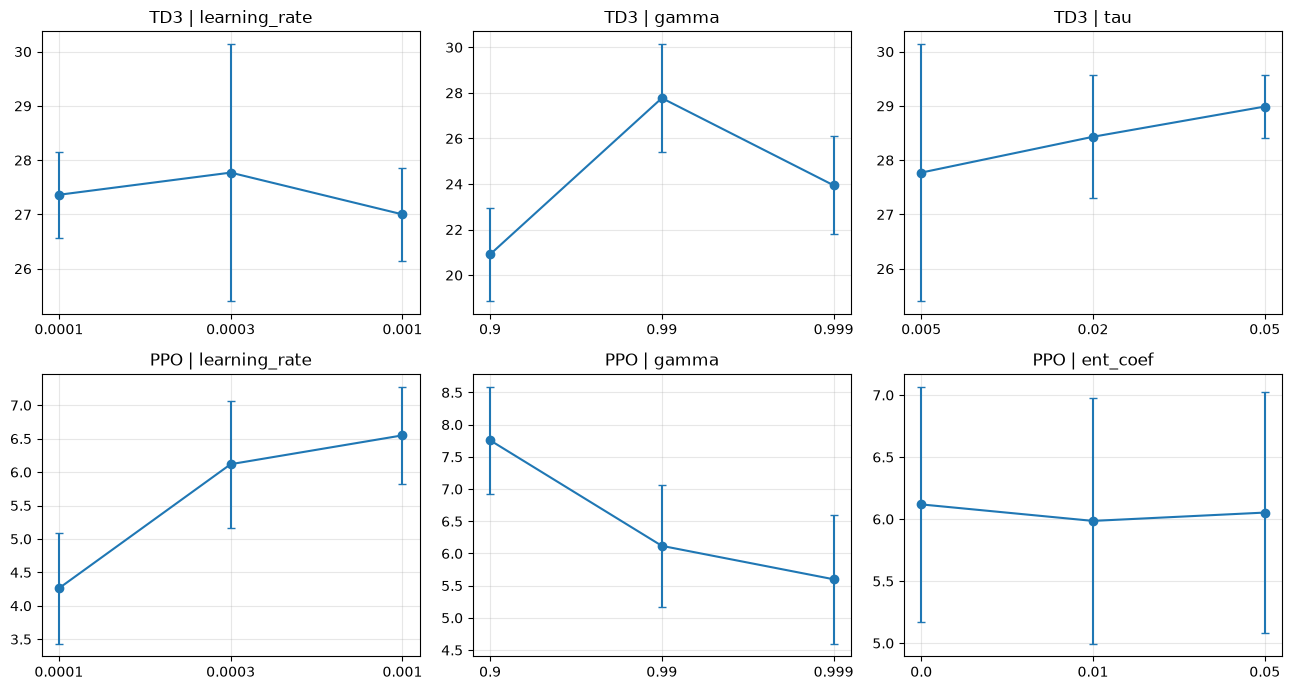


Cell 3 completed successfully.
PHASE 16 COMPLETED.


In [4]:
# Phase 16 – Cell 3: LR, Gamma, Tau, Entropy sensitivity (short train)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase16" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase16" / "figures"
OUT_MODEL = PROJECT / "outputs" / "phase16" / "models"
OUT_MODEL.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 16 – Cell 3: Hyperparameter sensitivity")
print("=" * 60)

# Short budget for sensitivity (equal across runs)
TIMESTEPS = 8000
EVAL_EP = 8
SEED = 0
SERIES = "standard"

def make_env(seed=0):
    return ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis", severity="Moderate",
        shock_series=SERIES, seed=seed,
    )

def eval_model(model, n_ep=EVAL_EP):
    rewards, srs = [], []
    for ep in range(n_ep):
        env = make_env(1000 + ep)
        obs, _ = env.reset(seed=1000 + ep)
        ep_r, done = 0.0, False
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(a)
            ep_r += float(r)
            done = term or trunc
        rewards.append(ep_r)
        sr = env.current_sr
        srs.append(float(np.mean(sr)) if np.ndim(sr) else float(sr))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.mean(srs))

rows = []

# ---- TD3: LR, Gamma, Tau ----
td3_grid = {
    "learning_rate": [1e-4, 3e-4, 1e-3],
    "gamma": [0.90, 0.99, 0.999],
    "tau": [0.005, 0.02, 0.05],
}

print("\n=== TD3 sensitivity ===")
for param, values in td3_grid.items():
    for val in values:
        kwargs = dict(learning_rate=3e-4, gamma=0.99, tau=0.005)
        kwargs[param] = val
        env = DummyVecEnv([lambda: make_env(SEED)])
        n_act = env.action_space.shape[0]
        noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
        model = TD3(
            "MlpPolicy", env, verbose=0, seed=SEED,
            action_noise=noise, **kwargs,
        )
        model.learn(TIMESTEPS)
        mean_r, std_r, mean_sr = eval_model(model)
        rows.append({
            "algo": "TD3", "param": param, "value": val,
            "timesteps": TIMESTEPS,
            "mean_reward": mean_r, "std_reward": std_r, "mean_sr": mean_sr,
        })
        print(f"  TD3 {param}={val} | R={mean_r:.3f}±{std_r:.3f} | SR={mean_sr:.3f}")

# ---- PPO: LR, Gamma, Entropy ----
ppo_grid = {
    "learning_rate": [1e-4, 3e-4, 1e-3],
    "gamma": [0.90, 0.99, 0.999],
    "ent_coef": [0.0, 0.01, 0.05],
}

print("\n=== PPO sensitivity ===")
for param, values in ppo_grid.items():
    for val in values:
        kwargs = dict(learning_rate=3e-4, gamma=0.99, ent_coef=0.0)
        kwargs[param] = val
        # PPO on structural env if available; else same shock env
        try:
            from economics_env import EconomicsNetworkEnv
            def _ppo_env():
                return EconomicsNetworkEnv(
                    base_features, emb, sr_vector, panel, nodes,
                    level="moderate", seed=SEED,
                )
            env = DummyVecEnv([_ppo_env])
        except Exception:
            env = DummyVecEnv([lambda: make_env(SEED)])
        model = PPO("MlpPolicy", env, verbose=0, seed=SEED, **kwargs)
        model.learn(TIMESTEPS)
        # evaluate on shock env for comparable metric
        mean_r, std_r, mean_sr = eval_model(model)
        rows.append({
            "algo": "PPO", "param": param, "value": val,
            "timesteps": TIMESTEPS,
            "mean_reward": mean_r, "std_reward": std_r, "mean_sr": mean_sr,
        })
        print(f"  PPO {param}={val} | R={mean_r:.3f}±{std_r:.3f} | SR={mean_sr:.3f}")

sens = pd.DataFrame(rows)
sens.to_csv(OUT_TAB / "sens_hyperparams.csv", index=False)

# range sensitivity index per param
idx_rows = []
for (algo, param), g in sens.groupby(["algo", "param"]):
    rmax, rmin = g["mean_reward"].max(), g["mean_reward"].min()
    idx_rows.append({
        "algo": algo,
        "param": param,
        "reward_range": float(rmax - rmin),
        "sr_range": float(g["mean_sr"].max() - g["mean_sr"].min()),
        "best_value": g.loc[g["mean_reward"].idxmax(), "value"],
        "best_reward": float(rmax),
    })
idx = pd.DataFrame(idx_rows).sort_values(["algo", "reward_range"], ascending=[True, False])
idx.to_csv(OUT_TAB / "sens_hyperparams_index.csv", index=False)
print("\n=== Sensitivity index (reward range) ===")
print(idx.to_string(index=False))

# plots
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_list = [
    ("TD3", "learning_rate"), ("TD3", "gamma"), ("TD3", "tau"),
    ("PPO", "learning_rate"), ("PPO", "gamma"), ("PPO", "ent_coef"),
]
for ax, (algo, param) in zip(axes.ravel(), plot_list):
    sub = sens[(sens.algo == algo) & (sens.param == param)].sort_values("value")
    ax.errorbar(sub["value"].astype(str), sub["mean_reward"], yerr=sub["std_reward"],
                marker="o", capsize=3)
    ax.set_title(f"{algo} | {param}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase16_hyperparam_sensitivity.png", dpi=150)
plt.show()

print("\nCell 3 completed successfully.")
print("PHASE 16 COMPLETED.")